# Projet Machine Learning (Regression)

Durant ce projet on suivras les étapes suivantes : 
* Data engineering (nettoyage des données, normalisation, codage)
* Sélection et extraction des caractéristiques (Matrice de corrélation, ACP, t-SNE, …)
* Visualisation des caractéristiques
* Choix des modèles avec leur cross-validation
* Résultats / métriques (Classification : Matrice de confusion)

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# =====================================================================
# A. CHARGEMENT ET NETTOYAGE DES DONNÉES
# =====================================================================
nom_fichier = "penguins.csv"

if os.path.exists(nom_fichier):
    df_raw = pd.read_csv(nom_fichier)
else:
    import seaborn as sns

    df_raw = sns.load_dataset("penguins")
    df_raw.to_csv(nom_fichier, index=False)

# Suppression des valeurs manquantes (lignes incomplètes)
df_clean = df_raw.dropna().copy()
print(f"Dataset nettoyé : {len(df_clean)} lignes disponibles.")

# =====================================================================
# B. SÉPARATION DES FEATURES (X) ET DE LA CIBLE (y)
# =====================================================================
# Notre cible "difficile" : la longueur du bec
y_reg = df_clean["bill_length_mm"].values

# Nos variables explicatives (on retire la cible)
X_reg_raw = df_clean.drop(columns=["bill_length_mm"])

print("\nCible (y) choisie : 'bill_length_mm' (Régression)")
print(f"Variables explicatives brutes (X) : {list(X_reg_raw.columns)}")

# =====================================================================
# C. CODAGE DES VARIABLES CATÉGORIELLES (One-Hot Encoding)
# =====================================================================
# Nous avons 3 variables catégorielles : species, island, sex
# On utilise drop='first' pour éviter le piège de la colinéarité (dummy variable trap)
# qui perturbe fortement les modèles linéaires comme la Régression Linéaire.
X_reg_encoded = pd.get_dummies(
    X_reg_raw, columns=["species", "island", "sex"], drop_first=True
)

# Conversion des colonnes booléennes (True/False) en numériques (1/0)
for col in X_reg_encoded.columns:
    if X_reg_encoded[col].dtype == "bool":
        X_reg_encoded[col] = X_reg_encoded[col].astype(int)

print("\n--- Après Encodage des variables catégorielles ---")
print(f"Nouvelles dimensions de X : {X_reg_encoded.shape}")
print(f"Liste des caractéristiques après encodage : \n{list(X_reg_encoded.columns)}")

# =====================================================================
# D. SÉPARATION EN TRAIN / TEST SET
# =====================================================================
# On met de côté 20% des données pour le test final
# Correction : on utilise bien X_reg_encoded qui a été défini plus haut
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_encoded, y_reg, test_size=0.2, random_state=42
)

# =====================================================================
# E. NORMALISATION (Scaling)
# =====================================================================
# Liste des variables numériques restantes dans X
features_num_reg = ["bill_depth_mm", "flipper_length_mm", "body_mass_g"]

# On crée une copie pour stocker les données scalées
X_train_scaled = X_train_reg.copy()
X_test_scaled = X_test_reg.copy()

# Initialisation du StandardScaler
scaler = StandardScaler()

# On fit UNIQUEMENT sur le Train Set pour éviter le Data Leakage
X_train_scaled[features_num_reg] = scaler.fit_transform(
    X_train_reg[features_num_reg]
)
X_test_scaled[features_num_reg] = scaler.transform(X_test_reg[features_num_reg])

print("\n=====================================================================")
print("             DATA ENGINEERING POUR LA RÉGRESSION TERMINÉ             ")
print("=====================================================================")
print(f"X_train_scaled prêt : {X_train_scaled.shape}")
print(f"X_test_scaled prêt  : {X_test_scaled.shape}")

Dataset nettoyé : 333 lignes disponibles.

Cible (y) choisie : 'bill_length_mm' (Régression)
Variables explicatives brutes (X) : ['species', 'island', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

--- Après Encodage des variables catégorielles ---
Nouvelles dimensions de X : (333, 8)
Liste des caractéristiques après encodage : 
['bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'species_Chinstrap', 'species_Gentoo', 'island_Dream', 'island_Torgersen', 'sex_Male']

             DATA ENGINEERING POUR LA RÉGRESSION TERMINÉ             
X_train_scaled prêt : (266, 8)
X_test_scaled prêt  : (67, 8)


A. Chargement et nettoyage des données
* Action : Chargement du fichier et suppression des lignes contenant des valeurs manquantes (NaN).
* Résultat : Un échantillon propre et exploitable de 333 manchots.

B. Séparation des features (X) et de la cible (y)
* Action : Isolation de la variable continue à prédire (bill_length_mm) dans le vecteur y, et conservation des autres variables explicatives dans la matrice X.

C. Codage des variables catégorielles (One-Hot Encoding)
* Action : Transformation des variables textuelles (species, island, sex) en variables numériques binaires (0 ou 1) via pd.get_dummies.
* Résultat : Le tableau de caractéristiques (X) passe de 6 à 8 dimensions.

D. Séparation en Train / Test Set
* Action : Division du jeu de données avec 80 % pour l'entraînement (266 manchots) et 20 % mis de côté pour le test final (67 manchots).
* Particularité : Contrairement à la classification, l'argument stratify n'est pas utilisable ici car la cible est une valeur numérique continue.

E. Normalisation (Scaling)
* Action : Application d'un StandardScaler (centrage-réduction) sur les variables numériques restantes (bill_depth_mm, flipper_length_mm, body_mass_g).

2. Sélection, extraction et visualisation des caractéristiques

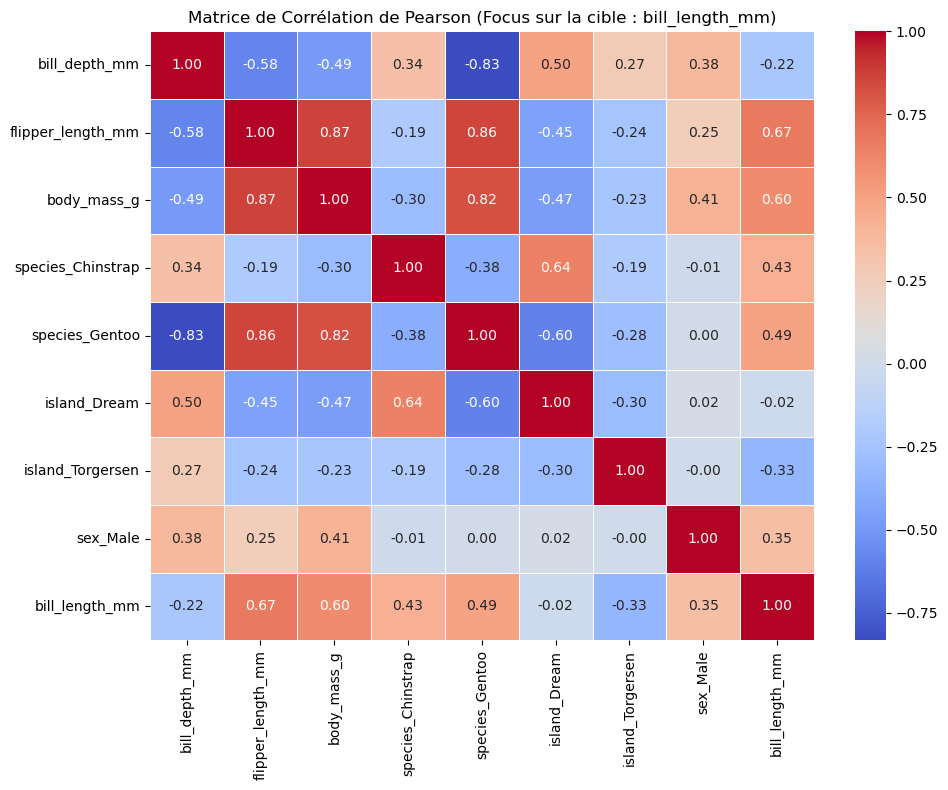

--- Corrélation des caractéristiques avec la cible (bill_length_mm) ---
bill_length_mm       1.000000
flipper_length_mm    0.672182
body_mass_g          0.602055
species_Gentoo       0.494374
species_Chinstrap    0.429375
sex_Male             0.350749
island_Dream        -0.017324
bill_depth_mm       -0.223472
island_Torgersen    -0.333579
Name: bill_length_mm, dtype: float64


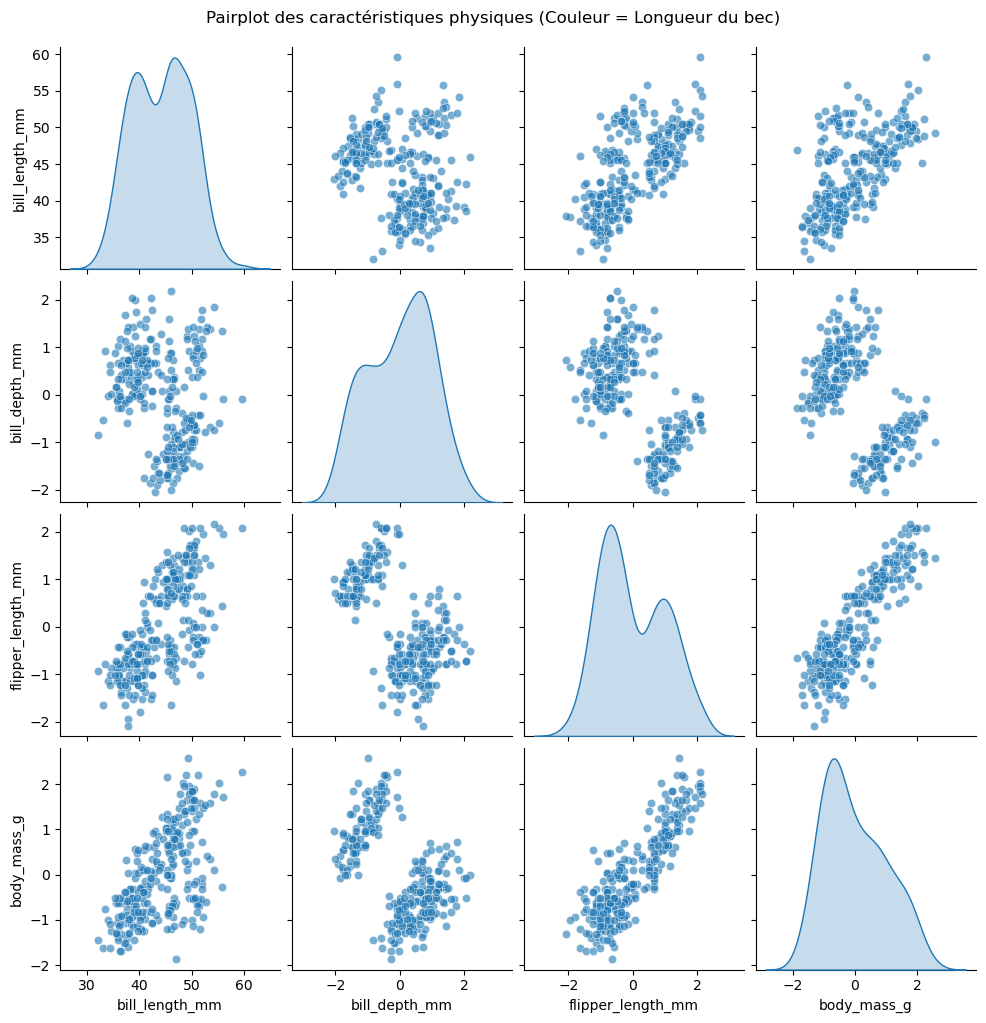

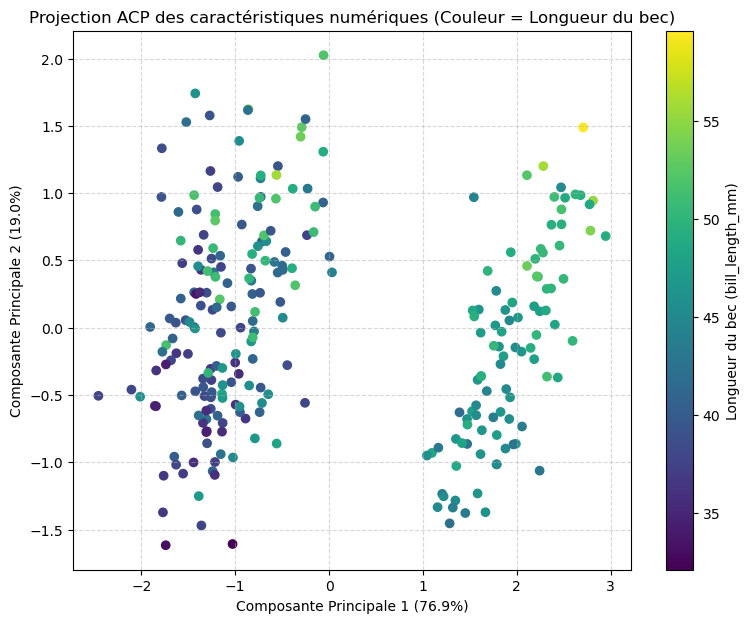


--- Analyse de l'ACP ---
Variance totale expliquée par les 2 composantes : 95.90%


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

# On recrée temporairement un DataFrame d'entraînement complet (X + y) pour les analyses graphiques
df_train_analysis = X_train_scaled.copy()
df_train_analysis["bill_length_mm"] = y_train_reg

# =====================================================================
# A. MATRICE DE CORRÉLATION
# =====================================================================
plt.figure(figsize=(10, 8))

# Calcul des corrélations de Pearson
corr_matrix = df_train_analysis.corr()

# Affichage de la Heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title(
    "Matrice de Corrélation de Pearson (Focus sur la cible : bill_length_mm)"
)
plt.tight_layout()
plt.show()

# Extraction des corrélations avec la cible triées par intensité
print("--- Corrélation des caractéristiques avec la cible (bill_length_mm) ---")
print(corr_matrix["bill_length_mm"].sort_values(ascending=False))

# =====================================================================
# B. VISUALISATION PAR PAIRPLOT (AVEC NUANCES DE LA CIBLE)
# =====================================================================
# On sélectionne les variables numériques d'origine pour le pairplot
vars_pairplot = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

# Le paramètre 'palette' utilise un dégradé (viridis) basé sur la valeur continue du bec
grid = sns.pairplot(
    df_train_analysis[vars_pairplot],
    diag_kind="kde",
    plot_kws={"alpha": 0.6, "palette": "viridis"},
)
grid.fig.suptitle(
    "Pairplot des caractéristiques physiques (Couleur = Longueur du bec)",
    y=1.02,
)
plt.show()

# =====================================================================
# C. ANALYSE EN COMPOSANTES PRINCIPALES (ACP)
# =====================================================================
# L'ACP se fait uniquement sur les features numériques de X_train (pas sur y)
features_num_reg = ["bill_depth_mm", "flipper_length_mm", "body_mass_g"]

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled[features_num_reg])

# Création d'un DataFrame pour la visualisation de l'ACP
df_pca = pd.DataFrame(data=X_train_pca, columns=["PC1", "PC2"])
df_pca["bill_length_mm"] = y_train_reg

# Affichage de la projection ACP
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    df_pca["PC1"], df_pca["PC2"], c=df_pca["bill_length_mm"], cmap="viridis"
)
plt.colorbar(scatter, label="Longueur du bec (bill_length_mm)")
plt.xlabel(
    f"Composante Principale 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)
plt.ylabel(
    f"Composante Principale 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)
plt.title(
    "Projection ACP des caractéristiques numériques (Couleur = Longueur du bec)"
)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print("\n--- Analyse de l'ACP ---")
print(
    f"Variance totale expliquée par les 2 composantes : {np.sum(pca.explained_variance_ratio_)*100:.2f}%"
)

A. Analyse de la matrice de corrélation
* La variable cible bill_length_mm possède de fortes liaisons linéaires positives avec les caractéristiques de taille générale : la longueur des nageoires (0,67) et la masse corporelle (0,60).
* Les variables catégorielles confirment l'impact de la génétique : appartenir à l'espèce Gentoo (0,49) ou Chinstrap (0,43), ou être un individu mâle sex_Male (0,35) favorise l'obtention d'un bec plus long.

B. Analyse de la projection ACP et du Pairplot
* L'ACP capture 95,9 % de la variance totale avec seulement deux composantes (PC1 = 76,9 %, PC2 = 19,0 %).
* La distribution des couleurs (longueur du bec) sur le graphique ACP met en évidence un gradient linéaire évident : les becs les plus courts (violet) sont regroupés à gauche et augmentent de taille de manière continue et rectiligne vers la droite (jaune).

3. Choix des modèles avec leur cross-validation

Régression Polynomiale (degré 2) : Elle est testée pour évaluer l'hypothèse d'une non-linéarité résiduelle non capturée par l'OLS. Si le jeu de données présente des effets quadratiques (par exemple, un seuil de croissance du bec à partir d'une certaine masse), ce modèle devrait en bénéficier.
Résultat observé : La performance (R² = 0,79 vs 0,82 pour l'OLS) confirme l'absence de relations forte non-linéaires utiles et révèle une tendance au surapprentissage.

Ridge (Régression L2) : Même si l'OLS performe bien, Ridge est testé pour vérifier si la présence de variables potentiellement corrélées (les variables encodées peuvent être partiellement liées) nécessite une stabilisation des coefficients. L'hyperparamètre alpha est optimisé par GridSearch sur [0.01, 0.1, 1.0, 10.0, 100.0].

Lasso (Régression L1) : Testé pour vérifier si certaines variables encodées sont redondantes et peuvent être éliminées sans perte de précision. La sous-performance observée (R² = 0,80) suggère que toutes les variables contribuent à la prédiction et que la sélection forcée par L1 supprime des informations utiles.

Elastic Net : Pertinent lorsque plusieurs variables sont corrélées et que l'on souhaite à la fois sélectionner un sous-ensemble et régulariser les coefficients restants. Deux hyperparamètres (alpha et l1_ratio) sont optimisés en même temps.

Descente de Gradient Stochastique (SGDRegressor) : Il est inclus comme représentant des méthodes d'optimisation numérique "scalables".

Arbre de Décision (Régression) : Permet de capturer des interactions non-linéaires complexes entre variables (par exemple, une règle du type 'si espèce=Gentoo ET flipper>200mm, alors bec long'). Sert également de brique de base pour le Gradient Boosting.

Gradient Boosting : Sa capacité à modéliser des relations non-linéaires complexes et des interactions d'ordre élevé en fait un candidat prométeur, même si les résultats confirment que la structure linéaire du problème limite son avantage ici.

Voting Regressor (Ensemble) : .L'agrégation de prédicteurs diversifiés peut réduire la variance globale même si chaque modèle est imparfait (principe de sagesse des foules). Son inclusion permet de vérifier si la combinaison de modèles hétérogènes améliore la performance par rapport au meilleur modèle individuel.


In [3]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, VotingRegressor
from sklearn.linear_model import (
    ElasticNet,
    Lasso,
    LinearRegression,
    Ridge,
    SGDRegressor,
)
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor

# =====================================================================
# 1. INITIALISATION DES MODÈLES (INCLUANT LE GRADIENT BOOSTING)
# =====================================================================

# Pour la Régression Polynomiale, on crée un Pipeline (Degré 2)
poly_pipeline = Pipeline(
    [
        ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
        ("linear_regression", LinearRegression()),
    ]
)

modeles_reg = {
    "Moindres Carrés (Linéaire)": LinearRegression(),
    "Régression Polynomiale (d=2)": poly_pipeline,
    "Ridge (L2)": Ridge(alpha=1.0, random_state=42),
    "Lasso (L1)": Lasso(alpha=0.1, random_state=42),
    "Elastic Net": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
    "Descente de Gradient (SGD)": SGDRegressor(max_iter=2000, random_state=42),
    "Arbre de Décision (Régression)": DecisionTreeRegressor(
        max_depth=5, random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42
    ),
}

# =====================================================================
# 2. AJOUT DU MODÈLE D'ENSEMBLE (VOTING REGRESSOR)
# =====================================================================
# Le VotingRegressor va faire la moyenne des prédictions de nos modèles.
liste_estimateurs = [(nom, modele) for nom, modele in modeles_reg.items()]
modeles_reg["Voting Regressor (Ensemble)"] = VotingRegressor(
    estimators=liste_estimateurs
)

# =====================================================================
# 3. EVALUATION PAR CROSS-VALIDATION (5-FOLD)
# =====================================================================
print(
    "--- Évaluation des modèles de Régression par Cross-Validation (5-Fold) ---"
)

# Configuration de la validation croisée (KFold classique pour la régression)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Dictionnaires pour stocker les résultats finaux
synthese_r2 = {}
synthese_rmse = {}

for nom, modele in modeles_reg.items():
    # On demande à cross_validate de calculer le R2 et la MSE négative
    scores = cross_validate(
        modele,
        X_train_scaled,
        y_train_reg,
        cv=kf,
        scoring=("r2", "neg_root_mean_squared_error"),
        n_jobs=-1,
    )

    # Récupération des scores (on inverse le signe du RMSE)
    r2_moyen = np.mean(scores["test_r2"])
    r2_std = np.std(scores["test_r2"])
    rmse_moyen = np.mean(-scores["test_neg_root_mean_squared_error"])
    rmse_std = np.std(-scores["test_neg_root_mean_squared_error"])

    # Sauvegarde
    synthese_r2[nom] = (r2_moyen, r2_std)
    synthese_rmse[nom] = (rmse_moyen, rmse_std)

    print(f"\n> {nom} :")
    print(f"  -> R² Moyen    : {r2_moyen:.4f} (+/- {r2_std:.4f})")
    print(f"  -> RMSE Moyen  : {rmse_moyen:.2f} mm (+/- {rmse_std:.2f} mm)")

# =====================================================================
# 4. AFFICHAGE DU TABLEAU COMPARATIF FINAL
# =====================================================================
print("\n" + "=" * 75)
print("             TABLEAU COMPARATIF DES PERFORMANCES DE RÉGRESSION             ")
print("=" * 75)

df_perf = pd.DataFrame(
    {
        "R² Moyen": [v[0] for v in synthese_r2.values()],
        "R² Écart-type": [v[1] for v in synthese_r2.values()],
        "RMSE Moyen (mm)": [v[0] for v in synthese_rmse.values()],
        "RMSE Écart-type": [v[1] for v in synthese_rmse.values()],
    },
    index=synthese_r2.keys(),
)

# Tri du tableau du meilleur au moins bon modèle (selon le R²)
df_perf = df_perf.sort_values(by="R² Moyen", ascending=False)
print(df_perf.to_string())

--- Évaluation des modèles de Régression par Cross-Validation (5-Fold) ---

> Moindres Carrés (Linéaire) :
  -> R² Moyen    : 0.8235 (+/- 0.0287)
  -> RMSE Moyen  : 2.19 mm (+/- 0.18 mm)

> Régression Polynomiale (d=2) :
  -> R² Moyen    : 0.7939 (+/- 0.0299)
  -> RMSE Moyen  : 2.37 mm (+/- 0.19 mm)

> Ridge (L2) :
  -> R² Moyen    : 0.8232 (+/- 0.0338)
  -> RMSE Moyen  : 2.18 mm (+/- 0.22 mm)

> Lasso (L1) :
  -> R² Moyen    : 0.8055 (+/- 0.0418)
  -> RMSE Moyen  : 2.29 mm (+/- 0.25 mm)

> Elastic Net :
  -> R² Moyen    : 0.7728 (+/- 0.0488)
  -> RMSE Moyen  : 2.48 mm (+/- 0.29 mm)

> Descente de Gradient (SGD) :
  -> R² Moyen    : 0.8052 (+/- 0.0183)
  -> RMSE Moyen  : 2.30 mm (+/- 0.11 mm)

> Arbre de Décision (Régression) :
  -> R² Moyen    : 0.7299 (+/- 0.1027)
  -> RMSE Moyen  : 2.68 mm (+/- 0.49 mm)

> Gradient Boosting :
  -> R² Moyen    : 0.7718 (+/- 0.0463)
  -> RMSE Moyen  : 2.49 mm (+/- 0.26 mm)

> Voting Regressor (Ensemble) :
  -> R² Moyen    : 0.8194 (+/- 0.0331)
  -> RM

Modèles optimaux : La régression linéaire classique et la régression Ridge sont les plus performantes (R² > 0.82, RMSE < 2.20 mm). L'équivalence de leurs scores indique que la régularisation L2 n'apporte pas de gain significatif sur ce jeu de données.

Impact de la régularisation L1 : Le Lasso et l'Elastic Net réduisent la précision (R² entre 0.77 et 0.80). Cela suggère que la sélection de variables (mise à zéro des coefficients par la norme L1) supprime des caractéristiques prédictives utiles.

Complexité non justifiée : La régression polynomiale de degré 2 sous-performe par rapport aux modèles linéaires simples (R² = 0.7939, RMSE = 2.37 mm), signalant une absence de relations non linéaires bénéfiques et une tendance au surapprentissage.

Stabilité : La descente de gradient (SGD) affiche la variance la plus faible sur l'erreur (+/- 0.11 mm), démontrant une bonne stabilité lors de la validation croisée, malgré un pouvoir prédictif inférieur aux modèles optimaux.

Pour des raisons d'efficacité, cette étape (usage des hyper-paramètres) est appliquée à trois modèles où il peut y avoir amélioration ou nécessitant un ajustement fin : Ridge, Elastic Net et Gradient Boosting. La métrique d'optimisation cible le RMSE.

In [4]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor

# =====================================================================
# 1. DÉFINITION DES MODÈLES ET DE LEURS GRILLES D'HYPERPARAMÈTRES
# =====================================================================
modeles_grilles = {
    "Ridge": (
        Ridge(random_state=42),
        {
            "alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
        }
    ),
    "Elastic Net": (
        ElasticNet(random_state=42),
        {
            "alpha": [0.01, 0.1, 1.0, 10.0],
            "l1_ratio": [0.1, 0.5, 0.7, 0.9, 1.0]
        }
    ),
    "Gradient Boosting": (
        GradientBoostingRegressor(random_state=42),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
            "max_depth": [2, 3, 4, 5]
        }
    )
}

# Configuration de la validation croisée (identique à l'étape précédente)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# =====================================================================
# 2. RECHERCHE DES MEILLEURS HYPERPARAMÈTRES (GRID SEARCH)
# =====================================================================
print("--- Optimisation des hyperparamètres par GridSearchCV (5-Fold) ---\n")

resultats_opti = []
meilleurs_modeles = {} # Dictionnaire pour stocker les modèles optimisés pour un usage futur

for nom, (modele, grille) in modeles_grilles.items():
    # GridSearchCV configure et évalue toutes les combinaisons de la grille
    grid_search = GridSearchCV(
        estimator=modele,
        param_grid=grille,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    
    # Entraînement
    grid_search.fit(X_train_scaled, y_train_reg)
    
    # Extraction des résultats (inversion du signe pour le RMSE)
    meilleur_rmse = -grid_search.best_score_
    meilleurs_params = grid_search.best_params_
    
    # Sauvegarde du meilleur modèle instancié
    meilleurs_modeles[nom] = grid_search.best_estimator_
    
    resultats_opti.append({
        "Modèle": nom,
        "RMSE Optimal (mm)": meilleur_rmse,
        "Meilleurs Paramètres": meilleurs_params
    })

# =====================================================================
# 3. AFFICHAGE DES RÉSULTATS D'OPTIMISATION
# =====================================================================
df_opti = pd.DataFrame(resultats_opti)
df_opti = df_opti.sort_values(by="RMSE Optimal (mm)", ascending=True)

print("=" * 85)
print("             TABLEAU COMPARATIF APRÈS OPTIMISATION (Classé par RMSE)             ")
print("=" * 85)
pd.set_option('display.max_colwidth', None) # Permet d'afficher les dictionnaires de paramètres en entier
print(df_opti.to_string(index=False))

--- Optimisation des hyperparamètres par GridSearchCV (5-Fold) ---

             TABLEAU COMPARATIF APRÈS OPTIMISATION (Classé par RMSE)             
           Modèle  RMSE Optimal (mm)                                         Meilleurs Paramètres
            Ridge           2.183932                                               {'alpha': 0.1}
      Elastic Net           2.184401                             {'alpha': 0.01, 'l1_ratio': 1.0}
Gradient Boosting           2.430173 {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


--- ÉVALUATION FINALE SUR L'ENSEMBLE DE TEST ---
Modèle retenu : Ridge (alpha=0.1)
R² (Test)     : 0.7997
RMSE (Test)   : 2.5480 mm


c:\Users\Aorus\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


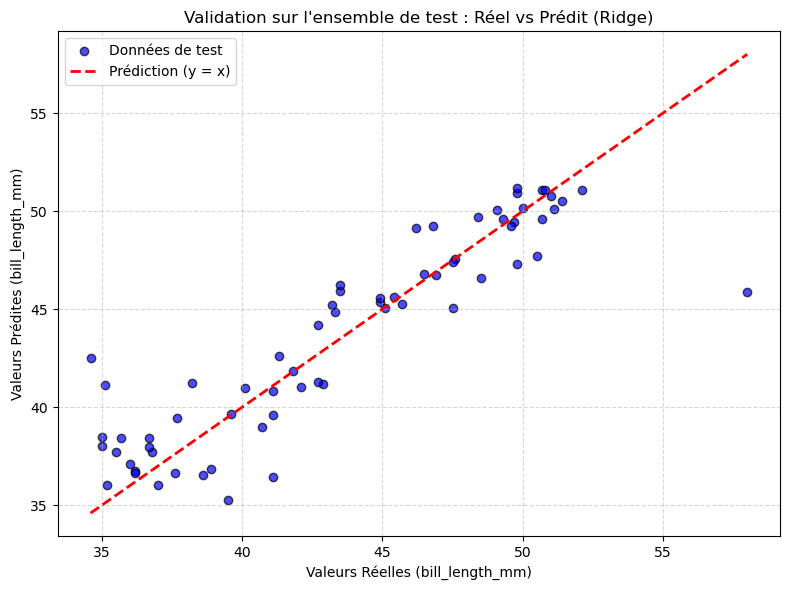

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# =====================================================================
# 1. PRÉDICTION ET CALCUL DES MÉTRIQUES SUR LES DONNÉES TEST
# =====================================================================

# Récupération du meilleur modèle Ridge issu du GridSearchCV
modele_final = meilleurs_modeles["Ridge"]

# Prédiction sur l'ensemble de test
y_pred_test = modele_final.predict(X_test_scaled)

# Calcul des métriques de généralisation
r2_test = r2_score(y_test_reg, y_pred_test)
rmse_test = mean_squared_error(y_test_reg, y_pred_test, squared=False)

print("--- ÉVALUATION FINALE SUR L'ENSEMBLE DE TEST ---")
print(f"Modèle retenu : Ridge (alpha=0.1)")
print(f"R² (Test)     : {r2_test:.4f}")
print(f"RMSE (Test)   : {rmse_test:.4f} mm")

# =====================================================================
# 2. GRAPHIQUE DE DIAGNOSTIC : VALEURS RÉELLES VS VALEURS PRÉDITES
# =====================================================================
plt.figure(figsize=(8, 6))

# Nuage de points
plt.scatter(y_test_reg, y_pred_test, alpha=0.7, color="b", edgecolors="k", label="Données de test")

# Ligne idéale (y_réel = y_prédit)
limites = [min(y_test_reg.min(), y_pred_test.min()), max(y_test_reg.max(), y_pred_test.max())]
plt.plot(limites, limites, "r--", lw=2, label="Prédiction (y = x)")

plt.xlabel("Valeurs Réelles (bill_length_mm)")
plt.ylabel("Valeurs Prédites (bill_length_mm)")
plt.title("Validation sur l'ensemble de test : Réel vs Prédit (Ridge)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Analyse des performances sur l'ensemble de test :
* Légère baisse de performance : Le $R^2$ passe de 0.8232 (en validation croisée) à 0.7997 sur l'ensemble de test. Parallèlement, le RMSE augmente, passant de 2.18 mm à 2.5480 mm.
* Diagnostic de surapprentissage : Le RMSE de test (2.55 mm) se situe légèrement au-dessus de la borne supérieure constatée lors de la validation croisée ($2.18 \pm 0.22$ mm, soit 2.40 mm). Cela indique un léger surapprentissage ou une sensibilité à la répartition spécifique du jeu de test.
* Capacité de généralisation : Malgré ce recul, le modèle reste robuste et valide. Il explique toujours près de 80 % de la variance de la cible (bill_length_mm) sur des données totalement inédites.
* Ordre de grandeur de l'erreur : À l'échelle de la longueur du bec des manchots (généralement comprise entre 30 mm et 60 mm), une erreur moyenne de 2.55 mm représente une incertitude relative d'environ 5 % à 8 %, ce qui reste tout à fait acceptable pour cette application.